# 문제 5 — 4x4 동차변환 모듈과 최소자승법

회전과 병진을 **한 행렬로 묶는** 것이 동차변환입니다.

$$T=\begin{bmatrix}R & \mathbf{t}\\ \mathbf{0}^{\mathsf{T}} & 1\end{bmatrix}\in\mathbb{R}^{4\times 4}$$

이렇게 묶으면 여러 좌표계를 지나는 변환을 **행렬 곱 하나로 연결**할 수 있습니다(문제 6).

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 5-1 | `make_T`, `inv_T` 를 만들고 ① 곱하면 단위행렬 ② 일반 역행렬과 일치 두 가지로 검증 | `make_T`, `inv_T` |
| 5-2 | **점(w=1)과 방향(w=0)의 차이**를 확인하고 왜 그런지 설명 | `to_homogeneous`, `transform_point`, `transform_direction`, `transform_points` |
| 5-3 | 두 변환의 **합성 순서**가 바뀌면 결과가 달라짐을 확인하고 3D 로 나란히 비교 | — |
| 5-4 | `inv_T` 와 일반 역행렬의 **실행 시간 비교**, 차이를 연산량 관점에서 설명 | `inv_T_batch` |
| 5-5 | **최소자승법** — 과결정 캘리브레이션 문제를 정규방정식으로 풀고 `lstsq` 와 비교, 잔차 정량 평가 | `least_squares_normal_equation`, `rmse` |

> `inv_T` 는 **일반 역행렬 함수를 쓰지 말고** 회전 부분의 전치를 이용한 공식으로 구현합니다.
> `tests/test_transform.py` 도 함께 작성해 제출합니다.

In [225]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import rot_x, rot_y, rot_z
from src.transform import (inv_T, inv_T_batch, least_squares_normal_equation, make_T, rmse,
                           to_homogeneous, transform_direction, transform_point,
                           transform_points)
from src.vectors import det

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# --- 그림 헬퍼 (그대로 쓰면 됩니다) -----------------------------------------

def draw_frame(ax, T, scale=0.35, alpha=1.0, name=""):
    """동차변환 T 가 나타내는 좌표계를 그린다."""
    o = T[:3, 3]
    colors = ["r", "g", "b"]
    for i in range(3):
        v = T[:3, i] * scale
        ax.quiver(*o, *v, color=colors[i], alpha=alpha, arrow_length_ratio=0.18)
    if name:
        ax.text(*(o + 0.05), name, fontsize=9)


def setup_axes(ax, title, lim=1.0):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("준비 완료")

준비 완료


## 5-1. `make_T` 와 `inv_T` — 역변환은 전치로 끝난다

역변환을 일반 역행렬로 구할 필요가 없습니다.
$R$ 이 직교행렬이라 $R^{-1}=R^{\mathsf{T}}$ 이기 때문입니다.

$$T^{-1}=\begin{bmatrix}R^{\mathsf{T}} & -R^{\mathsf{T}}\mathbf{t}\\ \mathbf{0}^{\mathsf{T}} & 1\end{bmatrix}$$

**유도해 보세요.** $T^{-1}$ 을 $\begin{bmatrix}S&\mathbf{u}\\0&1\end{bmatrix}$ 로 두고
$TT^{-1}=I$ 를 풀면 $S$ 와 $\mathbf{u}$ 가 각각 무엇이 되는지 나옵니다.
이 식이 기하적으로 무슨 뜻인지도 한 문장으로 적어 보세요.

### 역변환 공식의 유도와 의미

- 유도: `T = [[R, t], [0^T, 1]], T^-1 = [[S, u], [0^T, 1]]  
T @ T^-1 = [[R @ S, R @ u + t], [0^T, 1]] = [[I, 0], [0^T, 1]]
1) R @ S = I  =>  S = R^-1 = R^T (직교행렬의 성질)
2) R @ u + t = 0  =>  R @ u = -t  =>  u = -R^T @ t`
- 의미: `기존의 평행이동 벡터를 단순히 반대 방향으로 빼주는 것이 아니라, 바뀐 좌표계의 시선(회전된 축)에 맞추어 사영하고 정렬한 만큼 평행이동`

In [226]:
R = rot_z(np.deg2rad(45.0)) @ rot_y(np.deg2rad(-30.0)) @ rot_x(np.deg2rad(15.0))
t = np.array([0.3, -0.2, 0.45])

# TODO: T = make_T(R, t), Ti = inv_T(T) 를 만들고
#       T, Ti, T @ Ti, np.linalg.inv(T) (# 검산용) 를 출력해 비교하세요.
T = make_T(R, t)
Ti = inv_T(T)
I_3 = np.eye(3)
I_4 = np.eye(4)
T_inv_np = np.linalg.inv(T)

print(T, Ti,"\n(단위행렬 검증) = ", T @ Ti)
print("\nnp.linalg.inv(T) (Numpy 검산) =\n", T_inv_np)

[[ 0.612372 -0.774519 -0.158494  0.3     ]
 [ 0.612372  0.591506 -0.524519 -0.2     ]
 [ 0.5       0.224144  0.836516  0.45    ]
 [ 0.        0.        0.        1.      ]] [[ 0.612372  0.612372  0.5      -0.286237]
 [-0.774519  0.591506  0.224144  0.249792]
 [-0.158494 -0.524519  0.836516 -0.433788]
 [ 0.        0.        0.        1.      ]] 
(단위행렬 검증) =  [[ 1. -0. -0. -0.]
 [-0.  1. -0.  0.]
 [-0. -0.  1.  0.]
 [ 0.  0.  0.  1.]]

np.linalg.inv(T) (Numpy 검산) =
 [[ 0.612372  0.612372  0.5      -0.286237]
 [-0.774519  0.591506  0.224144  0.249792]
 [-0.158494 -0.524519  0.836516 -0.433788]
 [ 0.        0.        0.        1.      ]]


In [227]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - ① T @ inv_T(T) == I, inv_T(T) @ T == I
cond1 = np.allclose(T@Ti, I_4) and np.allclose(Ti@T, I_4)
check("T @ inv_T(T) == I, inv_T(T) @ T == I", cond1)
#   - ② 일반 역행렬 np.linalg.inv 와 일치
cond2 = np.allclose(T_inv_np, Ti)
check("일반 역행렬 np.linalg.inv 와 일치", cond2)
#   - 역변환의 회전 부분도 회전행렬인가 (det = 1)
cond3 = np.isclose(det(Ti[:3,:3]),1.0)
check("역변환의 회전 부분도 회전행렬인가 (det = 1)", cond3)
#   - 마지막 행이 (0,0,0,1) 인가
cond4 = np.allclose(T[3,:],[0,0,0,1])
check("마지막 행이 (0,0,0,1) 인가", cond4)
#   - inv_T(inv_T(T)) == T
cond5 = np.allclose(inv_T(Ti), T)
check("inv_T(inv_T(T)) == T", cond5)
#   - 무작위 200개 변환에서도 모두 성립하는가
rng_200_test = True
for _ in range(200):
    rand_angles = rng.uniform(-np.pi, np.pi, 3)
    R_rand = rot_z(rand_angles[0]) @ rot_y(rand_angles[1]) @ rot_x(rand_angles[2])
    t_rand = rng.uniform(-10.0, 10.0, 3)

    T_rand = make_T(R_rand, t_rand)
    Ti_rand = inv_T(T_rand)
    T_inv_rng = np.linalg.inv(T_rand)

    cond6 = np.allclose(T_rand @ Ti_rand, I_4) and np.allclose(Ti_rand @ T_rand, I_4) and np.allclose(Ti_rand, T_inv_rng)

    if not cond6:
        rng_200_test = False
        break

check("무작위 200개 변환에서도 모두 성립하는가", rng_200_test)

[PASS] T @ inv_T(T) == I, inv_T(T) @ T == I
[PASS] 일반 역행렬 np.linalg.inv 와 일치
[PASS] 역변환의 회전 부분도 회전행렬인가 (det = 1)
[PASS] 마지막 행이 (0,0,0,1) 인가
[PASS] inv_T(inv_T(T)) == T
[PASS] 무작위 200개 변환에서도 모두 성립하는가


True

## 5-2. 점과 방향의 차이 — 마지막 성분 1 vs 0

동차좌표의 네 번째 성분 $w$ 가 의미를 가릅니다.

$$T\begin{bmatrix}\mathbf{p}\\1\end{bmatrix}=?
\qquad\qquad
T\begin{bmatrix}\mathbf{v}\\0\end{bmatrix}=?$$

**할 일**

- 같은 벡터를 점(w=1)과 방향(w=0)으로 각각 변환해 결과를 비교하세요.
- 두 결과의 **차이가 무엇과 같은지** 확인하고, 왜 그렇게 되는지 식에서 설명하세요.
- 물리적으로 무엇이 점이고 무엇이 방향인지(위치 / 속도·힘·법선벡터),
  이걸 헷갈리면 로봇에서 어떤 문제가 생기는지 적으세요.
- 보너스: **두 점의 차이**는 점처럼 변환될까요, 방향처럼 변환될까요? 코드로 확인하세요.

### 점과 방향이 다르게 변환되는 이유

- 식에서의 이유: `w = 0인 방향은 회전성분의 영향없이 회전만 하고(Rx) w = 1인 점은 회전과 이동 둘 다 영향을 줘서(Rx+t)`
- 물리적 의미: `점은 공간 상의 고정된 위치이고 방향은 위치가 아닌 크기와 방향성의 벡터라서`
- 헷갈리면 생기는 문제: `로봇 제어 시 방향에 점 변환을 적용 시 움직일때마다 속도나 힘이 증폭되거나 왜곡될 수도 있음`

In [228]:
v = np.array([1.0, 0.0, 0.0])

# TODO: transform_point / transform_direction 결과를 출력하고 차이를 확인하세요.
p_trans = transform_point(T, v)
d_trans = transform_direction(T, v)

print(f"원래 3D 벡터: {v}")
print(f"점(w=1)으로 변환된 결과: {p_trans}")
print(f"방향(w=0)으로 변환된 결과: {d_trans}")
print(f"두 결과의 차이 (점 - 방향): {p_trans - d_trans}")
# TODO: 길이가 보존되는 쪽은 어느 쪽인지도 출력해 보세요.
print(f"원래 벡터의 길이: {np.linalg.norm(v):.6f}")
print(f"변환된 점 벡터의 길이: {np.linalg.norm(p_trans):.6f}")
print(f"변환된 방향 벡터의 길이: {np.linalg.norm(d_trans):.6f}")
print(f"변환된 방향 벡터와의 보존 여부: {np.isclose(np.linalg.norm(v), np.linalg.norm(d_trans))})\n")
# TODO: 두 점의 차이 (p1 - p2) 를 방향으로 변환한 것과
#       변환된 p1 - 변환된 p2 를 비교하세요.
p1 = rng.uniform(-10, 10, 3)
p2 = rng.uniform(-10, 10, 3)
diff_p = p1 - p2

trans_diff_as_dir = transform_direction(T, diff_p)
trans_p1 = transform_point(T, p1)
trans_p2 = transform_point(T, p2)
diff_of_trans_p = trans_p1 - trans_p2

cond7 = np.allclose(diff_p,diff_of_trans_p)

print("p1-p2 = ", diff_p, "trans_p1-trans_p2", diff_of_trans_p, "일치 여부 : ", cond7)

원래 3D 벡터: [1. 0. 0.]
점(w=1)으로 변환된 결과: [0.912372 0.412372 0.95    ]
방향(w=0)으로 변환된 결과: [0.612372 0.612372 0.5     ]
두 결과의 차이 (점 - 방향): [ 0.3  -0.2   0.45]
원래 벡터의 길이: 1.000000
변환된 점 벡터의 길이: 1.380208
변환된 방향 벡터의 길이: 1.000000
변환된 방향 벡터와의 보존 여부: True)

p1-p2 =  [-2.882242 10.48662  15.581756] trans_p1-trans_p2 [-12.356702  -3.735031  13.943783] 일치 여부 :  False


In [229]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 점과 방향의 결과가 다른가
cond8 = not np.allclose(p_trans, d_trans)
check("점과 방향의 결과가 다른가", cond8)
#   - 그 차이가 정확히 병진 벡터 t 인가
cond9 = np.allclose(p_trans-d_trans, t)
check("그 차이가 정확히 병진 벡터 t 인가", cond9)
#   - 방향은 길이가 보존되는가 / 방향 변환이 R @ v 인가
cond10 = np.isclose(np.linalg.norm(v), np.linalg.norm(d_trans)) and np.allclose(d_trans, R@v)
check("방향은 길이가 보존되는가 / 방향 변환이 R @ v 인가", cond10)
#   - 점 변환이 R @ p + t 인가
cond11 = np.allclose(p_trans, R @ v + t)
check("점 변환이 R @ p + t 인가", cond11)
#   - 두 점의 차이는 방향처럼 변환되는가
cond12 = np.allclose(trans_diff_as_dir, diff_of_trans_p)
check("두 점의 차이는 방향처럼 변환되는가", cond12)
#   - 원점을 점으로 변환하면 t 인가 / 영벡터를 방향으로 변환하면 영벡터인가
origin_p = transform_point(T, np.zeros(3))
zero_d = transform_direction(T, np.zeros(3))
cond13 = np.allclose(origin_p, t) and np.allclose(zero_d, np.zeros(3))
check("원점을 점으로 변환하면 t 인가 / 영벡터를 방향으로 변환하면 영벡터인가", cond13)

[PASS] 점과 방향의 결과가 다른가
[PASS] 그 차이가 정확히 병진 벡터 t 인가
[PASS] 방향은 길이가 보존되는가 / 방향 변환이 R @ v 인가
[PASS] 점 변환이 R @ p + t 인가
[PASS] 두 점의 차이는 방향처럼 변환되는가
[PASS] 원점을 점으로 변환하면 t 인가 / 영벡터를 방향으로 변환하면 영벡터인가


True

## 5-3. 합성 순서가 바뀌면 결과가 다르다

회전과 마찬가지로 동차변환의 곱도 교환법칙이 성립하지 않습니다.
곱을 블록 단위로 전개해 보면 **회전이 병진을 끌고 도는** 구조가 보입니다.

$$T_1T_2=\begin{bmatrix}?&?\\0&1\end{bmatrix}
\qquad
T_2T_1=\begin{bmatrix}?&?\\0&1\end{bmatrix}$$

**할 일**

- 두 변환 $T_1, T_2$ 를 잡아 두 순서로 합성하고 회전 부분·병진 부분을 각각 비교하세요.
  (주의: 병진 벡터가 회전축과 나란하면 순서를 바꿔도 병진이 우연히 같아집니다.
   두 축 모두에 성분이 걸리도록 잡으세요.)
- 전개한 공식이 실제 계산과 맞는지 코드로 확인하세요.
- 두 결과 좌표계를 **3D 로 나란히 그려** 비교하세요.

### 블록 전개와 해석

- $T_1T_2$ 의 회전/병진: `R1R2/R1t2+t1`
- $T_2T_1$ 의 회전/병진: `R2R1/R2t1+t2`
- 일상적인 비유로 설명하면: `한 발자국 앞으로 간 후 우향우 한 것과 우향우하고 한 발자국 앞으로 간 것이 다르기 때문`

In [230]:
T1 = make_T(rot_z(np.deg2rad(90.0)), [0.5, 0.2, 0.0])    # z 90도 회전 + (0.5, 0.2, 0) 이동
T2 = make_T(rot_x(np.deg2rad(90.0)), [0.1, 0.0, 0.4])    # x 90도 회전 + (0.1, 0, 0.4) 이동

R1, t1 = T1[:3, :3], T1[:3, 3]
R2, t2 = T2[:3, :3], T2[:3, 3]
R_12 = R1 @ R2
R_21 = R2 @ R1
t_12 = R1 @ t2 + t1
t_21 = R2 @ t1 + t2

# TODO: C12 = T1 @ T2, C21 = T2 @ T1 을 만들고
#       두 행렬, 회전 부분 차이, 병진 부분을 각각 출력하세요.
C12 = T1 @ T2
C21 = T2 @ T1

print(f"T1 @ T2 = {C12}, T2 @ T1 = {C21}, 회전 부분 차이 = {R_12 - R_21}, 병진 부분 차이 = {t_12 - t_21}")
# TODO: 전개 공식(회전이 병진에 어떻게 걸리는지)이 맞는지 확인해 출력하세요.

T1 @ T2 = [[ 0.  -0.   1.   0.5]
 [ 1.   0.  -0.   0.3]
 [ 0.   1.   0.   0.4]
 [ 0.   0.   0.   1. ]], T2 @ T1 = [[ 0.  -1.   0.   0.6]
 [ 0.   0.  -1.   0. ]
 [ 1.   0.   0.   0.6]
 [ 0.   0.   0.   1. ]], 회전 부분 차이 = [[ 0.  1.  1.]
 [ 1.  0.  1.]
 [-1.  1.  0.]], 병진 부분 차이 = [-0.1  0.3 -0.2]


/tmp/ipykernel_15186/2805197979.py:29: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/2805197979.py:29: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/2805197979.py:29: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/2805197979.py:29: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/2805197979.py:29: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/pa4/git/OnChangbum_physicalai_lv1_assignments/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pa4/git/OnChangbum_physic

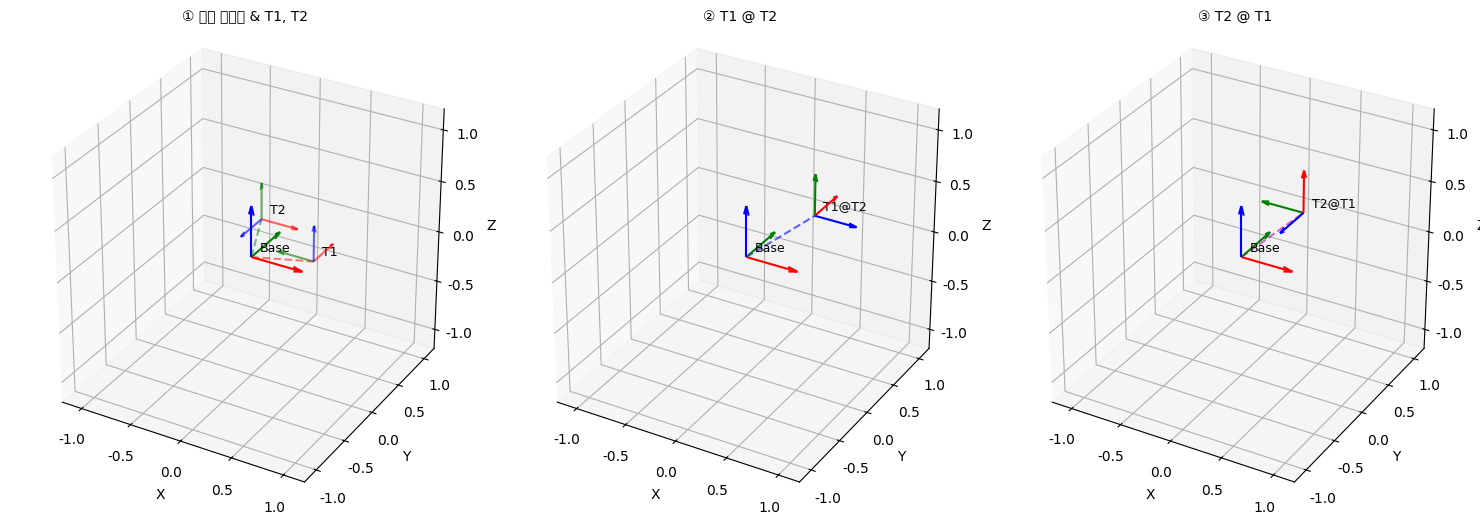

In [231]:
# TODO: 3분할 3D 그림을 그리세요.
#   ① 기준 좌표계와 T1, T2   ② T1 @ T2   ③ T2 @ T1
#   draw_frame / setup_axes 를 쓰고, 원점에서 각 좌표계 원점까지 점선을 그으면 비교가 쉽습니다.
fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": "3d"})

# ① 기준 좌표계와 T1, T2
setup_axes(axs[0], "① 기준 좌표계 & T1, T2", lim=1.2)
draw_frame(axs[0], I_4, scale=0.5, name="Base")
draw_frame(axs[0], T1, scale=0.35, alpha=0.6, name="T1")
draw_frame(axs[0], T2, scale=0.35, alpha=0.6, name="T2")
# 원점(0,0,0)에서 각 좌표계의 원점(병진 벡터 t)까지 점선 연결
axs[0].plot([0, t1[0]], [0, t1[1]], [0, t1[2]], 'r--', alpha=0.5)
axs[0].plot([0, t2[0]], [0, t2[1]], [0, t2[2]], 'g--', alpha=0.5)

# ② T1 @ T2 (T1을 먼저 수행하고 T2를 합성)
setup_axes(axs[1], "② T1 @ T2", lim=1.2)
draw_frame(axs[1], I_4, scale=0.5, name="Base")
draw_frame(axs[1], C12, scale=0.4, name="T1@T2")
# 원점에서 합성 좌표계 C12의 원점 위치까지 점선 연결
axs[1].plot([0, C12[0, 3]], [0, C12[1, 3]], [0, C12[2, 3]], 'b--', alpha=0.6)

# ③ T2 @ T1 (T2를 먼저 수행하고 T1을 합성)
setup_axes(axs[2], "③ T2 @ T1", lim=1.2)
draw_frame(axs[2], I_4, scale=0.5, name="Base")
draw_frame(axs[2], C21, scale=0.4, name="T2@T1")
# 원점에서 합성 좌표계 C21의 원점 위치까지 점선 연결
axs[2].plot([0, C21[0, 3]], [0, C21[1, 3]], [0, C21[2, 3]], 'm--', alpha=0.6)

plt.tight_layout()
plt.show()

In [232]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 두 합성 결과가 다른가 / 병진 부분도 다른가
cond14 = (not np.allclose(C12, C21)) and (not np.allclose(C12[:3, 3], C21[:3, 3]))
check("두 합성 결과가 다른가 / 병진 부분도 다른가", cond14)

# 전개한 합성 공식이 맞는가
cond15 = np.allclose(C12[:3, 3], t_12) and np.allclose(C21[:3, 3], t_21)
check("전개한 합성 공식이 맞는가", cond15)

# 두 결과 모두 유효한 동차변환인가 (회전부 det = 1)
cond16 = np.isclose(det(C12[:3, :3]), 1.0) and np.isclose(det(C21[:3, :3]), 1.0)
check("두 결과 모두 유효한 동차변환인가 (회전부 det = 1)", cond16)

# 역변환 순서가 뒤집히는가: (T1 T2)^-1 == T2^-1 T1^-1
inv_C12 = inv_T(C12)
inv_order = inv_T(T2) @ inv_T(T1)
cond17 = np.allclose(inv_C12, inv_order)
check("역변환 순서가 뒤집히는가: (T1 T2)^-1 == T2^-1 T1^-1", cond17)

[PASS] 두 합성 결과가 다른가 / 병진 부분도 다른가
[PASS] 전개한 합성 공식이 맞는가
[PASS] 두 결과 모두 유효한 동차변환인가 (회전부 det = 1)
[PASS] 역변환 순서가 뒤집히는가: (T1 T2)^-1 == T2^-1 T1^-1


True

## 5-4. `inv_T` vs 일반 역행렬 — 연산량 비교

두 방법이 각각 무슨 일을 하는지 세어 보세요.

| 방법 | 하는 일 | 연산량 |
|---|---|---|
| `inv_T` | `회전 행렬 부분의 전치(R^T) 및 역방향 평행이동 벡터 계산(-R^T * t)` | 약 `45` flops |
| `np.linalg.inv` | `LU 분해 및 가우스 소거 연산` | 약 `150` flops |

**주의** — 4x4 하나만 뒤집는 **단건 호출로는 이 차이가 잘 측정되지 않습니다.**
실제 연산은 수십 flops(나노초)뿐이고, 시간의 대부분은 파이썬 함수 호출과
NumPy 배열 생성 오버헤드(마이크로초)이기 때문입니다.

**할 일**

- 먼저 단건 호출로 측정해 보고, 결과가 예상과 다르면 **왜 그런지** 적으세요.
- `(N, 4, 4)` 묶음을 한 번에 뒤집는 `inv_T_batch` 를 구현해
  오버헤드를 상수화한 뒤 다시 비교하세요.
  (로봇 제어 루프에서 링크 수십 개의 변환을 매 주기 뒤집는 상황이 정확히 이 형태입니다)
- 정확도 관점의 차이도 하나 있습니다. 전치로 구한 역변환의 회전부 직교성 오차와
  일반 역행렬의 직교성 오차를 재서 비교해 보세요.

### 속도 차이의 해석

- 단건에서 차이가 나지 않는 이유: `파이썬 내부 연산이 순수 수학 연산 시간보다 압도적으로 크기 때문에 알고리즘 속도 차이가 묻힘`
- 배치에서 차이가 드러나는 이유: `전체 데이터에 대해 NumPy의 C-라이브러리 레벨 벡터화 연산을 한 번에 수행, 순수한 알고리즘 및 유효 연산량 격차가 여실히 드러남`
- 정확도 차이: `np.linalg.inv : 미세한 반올림 오차가 누적되어 회전부의 직교성이 훼손, inv_T : 완벽한 기계 정밀도 한계(오차 0에 근접)의 직교성을 보존`

In [233]:
N_REPEAT = 20000


def bench(fn, repeat):
    """워밍업 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - t0)
    return best


# TODO: 단건 호출로 inv_T 와 np.linalg.inv 의 1회 시간을 재서 출력하세요.
rand_angle = rng.uniform(-np.pi, np.pi, 3)
R_rng = rot_z(rand_angle[0]) @ rot_y(rand_angle[1]) @ rot_x(rand_angle[2])
t_rng = rng.uniform(-10.0, 10.0, 3)
T_single = make_T(R_rng, t_rng)

fn_single_inv_T = lambda: inv_T(T_single)
fn_single_np_inv = lambda: np.linalg.inv(T_single)

t_single_inv_T = bench(fn_single_inv_T, repeat=N_REPEAT)
t_single_np_inv = bench(fn_single_np_inv, repeat=N_REPEAT)

print(f"inv_T: {t_single_inv_T * 1e6:.3f} μs\n")
print(f"np.linalg.inv: {t_single_np_inv * 1e6:.3f} μs\n")

inv_T: 3.017 μs

np.linalg.inv: 2.939 μs



In [234]:
N_BATCH = 2000

# TODO: (N_BATCH, 4, 4) 변환 묶음을 만들고
#       inv_T_batch 와 np.linalg.inv(스택 입력) 의 시간을 비교 출력하세요.
T_batch = np.zeros((N_BATCH, 4, 4))

for i in range(N_BATCH):
    ang_i = rng.uniform(-np.pi, np.pi, 3)
    R_i = rot_z(ang_i[0]) @ rot_y(ang_i[1]) @ rot_z(ang_i[2])
    t_i = rng.uniform(-5.0, 5.0, 3)
    T_batch[i] = make_T(R_i, t_i)

fn_batch_inv_T = lambda: inv_T_batch(T_batch)
fn_batch_np_inv = lambda: np.linalg.inv(T_batch)

t_batch_inv_T = bench(fn_batch_inv_T, repeat=1000)
t_batch_np_inv = bench(fn_batch_np_inv, repeat=1000)

print(f"inv_T_batch: {t_batch_inv_T * 1000:.3f} ms\n np.linalg.inv: {t_batch_np_inv * 1000:.3f}ms\n")

# TODO: 두 방법의 회전부 직교성 오차도 비교 출력하세요.
out_batch_inv_T = inv_T_batch(T_batch)
out_batch_np_inv = np.linalg.inv(T_batch)

def calc_ortho_error_batch(T_stack):
    R_stack = T_stack[:, :3, :3]
    errors = []
    for i in range(len(R_stack)):
        diff = R_stack[i].T @ R_stack[i] - I_3
        errors.append(np.sqrt(np.sum(diff ** 2)))
    return np.max(errors)

ortho_err_inv_T = calc_ortho_error_batch(out_batch_inv_T)
ortho_err_np_inv = calc_ortho_error_batch(out_batch_np_inv)

print(f"inv_T_batch 회전부 직교성 최대 오차: {ortho_err_inv_T:.4e} np.linalg.inv 회전부 직교성 최대 오차: {ortho_err_np_inv:.4e}\n")

inv_T_batch: 0.108 ms
 np.linalg.inv: 0.433ms

inv_T_batch 회전부 직교성 최대 오차: 5.9666e-16 np.linalg.inv 회전부 직교성 최대 오차: 8.4120e-16



In [235]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 배치에서 inv_T_batch 가 일반 역행렬보다 빠른가
cond18 = t_batch_inv_T < t_batch_np_inv
check("배치에서 inv_T_batch 가 일반 역행렬보다 빠른가", t_batch_inv_T < t_batch_np_inv)
#   - inv_T 와 일반 역행렬의 결과가 같은가
cond19 = np.allclose(inv_T(T_single), np.linalg.inv(T_single))
check("inv_T 와 일반 역행렬의 결과가 같은가", cond19)
#   - inv_T_batch 결과 == np.linalg.inv 스택 결과
cond20 = np.allclose(out_batch_inv_T, out_batch_np_inv)
check("inv_T_batch 결과 == np.linalg.inv 스택 결과", cond20)
#   - inv_T_batch 결과 == inv_T 를 하나씩 적용한 결과
each_inv_T_res = np.array([inv_T(T_i) for T_i in T_batch])
cond21 = np.allclose(out_batch_inv_T, each_inv_T_res)
check("inv_T_batch 결과 == np.linalg.inv 스택 결과", cond21)
#   - inv_T 결과의 회전부가 완전한 직교인가
cond22 = ortho_err_inv_T < 1e-14
check("inv_T 결과의 회전부가 완전한 직교인가", cond22)

[PASS] 배치에서 inv_T_batch 가 일반 역행렬보다 빠른가
[PASS] inv_T 와 일반 역행렬의 결과가 같은가
[PASS] inv_T_batch 결과 == np.linalg.inv 스택 결과
[PASS] inv_T_batch 결과 == np.linalg.inv 스택 결과
[PASS] inv_T 결과의 회전부가 완전한 직교인가


True

## 5-5. 최소자승법 — 과결정 캘리브레이션 문제

**상황**: 카메라와 로봇 base 양쪽에서 좌표를 아는 대응점 $N$ 개가 있고,
이 대응을 설명하는 변환 $M=[R\,|\,\mathbf{t}]$ (12개 미지수)를 찾고 싶습니다.
측정에는 노이즈가 섞여 있고 대응점은 $N=30$ 개라 **방정식이 $3N=90$ 개, 미지수가 12 개**인
과결정(overdetermined) 문제입니다. 정확히 만족하는 해는 없으므로 오차 제곱합을 최소화합니다.

각 대응점은 다음 3 개의 선형방정식을 줍니다.

$$\mathbf{p}_{base} = M\begin{bmatrix}\mathbf{p}_{cam}\\1\end{bmatrix}
\;\Longrightarrow\;
\underbrace{(I_3\otimes[\mathbf{p}_{cam}^{\mathsf{T}}\;1])}_{3\times 12}\,\mathrm{vec}(M)=\mathbf{p}_{base}$$

최소자승해는 **정규방정식** $A^{\mathsf{T}}A\,\mathbf{x}=A^{\mathsf{T}}\mathbf{b}$ 에서 나옵니다.
이 식이 어디서 나오는지(잔차와 $A$ 의 열공간 사이의 관계) 직접 유도해 적어 보세요.

**할 일**

- 참값 변환을 하나 정하고, 대응점 30개에 1 mm 정도의 노이즈를 섞어 데이터를 만드세요.
- 설계행렬 $A$ (3N x 12) 와 관측 $b$ (3N,) 를 조립하세요. (힌트: `np.kron`)
- `least_squares_normal_equation` 으로 풀고 `np.linalg.lstsq` (# 비교 대상) 와 비교하세요.
- 잔차를 정량 평가하세요 — RMSE 가 주입한 노이즈와 같은 자릿수인지,
  잔차가 정말 $A$ 의 열공간에 수직인지($|A^{\mathsf{T}}r|$).
- 잔차 분포 히스토그램과 대응점별 재투영 오차 막대그래프를 그리세요.

### 정규방정식의 유도

- `r(x) = b - Ax, E(x) = abs(r)^2 -> A^T*A_x =  A^T * b`

In [236]:
N_PTS = 30
NOISE = 1e-3          # 1 mm 측정 노이즈

# TODO: 참값 변환 T_true 와 대응점 P_cam, 노이즈를 섞은 P_base 를 만드세요.
ang_true = rng.uniform(-np.pi, np.pi, 3)
R_true = rot_z(ang_true[0]) @ rot_y(ang_true[1]) @ rot_x(ang_true[2])
t_true = rng.uniform(-1.0, 1.0, 3)
T_true = make_T(R_true, t_true)
M_true = T_true[:3, :]

P_cam = rng.uniform(-1.0, 1.0, (N_PTS,3))
P_base = np.zeros((N_PTS,3))
for i in range(N_PTS):
    p_cam_hom = np.append(P_cam[i], 1.0)
    noise_vector = rng.normal(0.0, NOISE, 3)
    P_base[i] = (M_true @ p_cam_hom) + noise_vector

# TODO: 설계행렬 A_ls 와 관측 b_ls 를 조립하고 shape / 과결정 여부 / rank 를 출력하세요.
A_list = []
b_list = []

for i in range(N_PTS):
    p_cam_bar = np.append(P_cam[i], 1.0).reshape(1,4)
    A_block = np.kron(I_3, p_cam_bar)
    A_list.append(A_block)
    b_list.append(P_base[i])

A_ls = np.vstack(A_list)
b_ls = np.concatenate(b_list)
rank_A = np.linalg.matrix_rank(A_ls)

print(f"A_ls.shape = {A_ls.shape},\nb_ls.shape = {b_ls.shape},\n Rank(A_ls) = {rank_A}")

# TODO: least_squares_normal_equation 으로 풀어 M_hat 을 복원하고 참값과 비교하세요.
x_hat = least_squares_normal_equation(A_ls, b_ls)
M_hat = x_hat.reshape(3, 4)

# 대조군 및 평가지표 계산
x_lstsq, _, _, _ = np.linalg.lstsq(A_ls, b_ls, rcond=None)
r_vec = b_ls - A_ls @ x_hat
res_rmse = rmse(b_ls, A_ls @ x_hat)
ortho_condition = np.linalg.norm(A_ls.T @ r_vec)

# TODO: np.linalg.lstsq (# 비교 대상) 와 일치하는지, 잔차 RMSE 와 |A^T r| 을 출력하세요.
is_equal_lstsq = np.allclose(x_hat, x_lstsq)
print("x_hat == x_lstsq ? -> ", is_equal_lstsq)

# (2) 잔차 RMSE 출력 (m 단위 및 mm 단위 동시 변환 표시)
print(f"RMSE (오차 제곱근 평균) = {res_rmse:.6f} m = {res_rmse * 1000:.4f} mm)")
print(f"측정 노이즈 수준 = {NOISE * 1000:.1f} mm)")

# (3) |A^T r| 출력 (잔차가 설계행렬 A의 열공간에 수직인지 엄격 검증)
print(f"|A^T r| = {ortho_condition:.4e}")

A_ls.shape = (90, 12),
b_ls.shape = (90,),
 Rank(A_ls) = 12
x_hat == x_lstsq ? ->  True
RMSE (오차 제곱근 평균) = 0.000936 m = 0.9357 mm)
측정 노이즈 수준 = 1.0 mm)
|A^T r| = 8.2617e-15


/tmp/ipykernel_15186/1202773920.py:42: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/1202773920.py:42: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/1202773920.py:42: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/1202773920.py:42: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/1202773920.py:42: UserWarning: Glyph 52888 (\N{HANGUL SYLLABLE KAEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/1202773920.py:42: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15186/1202773920.py:42: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  plt

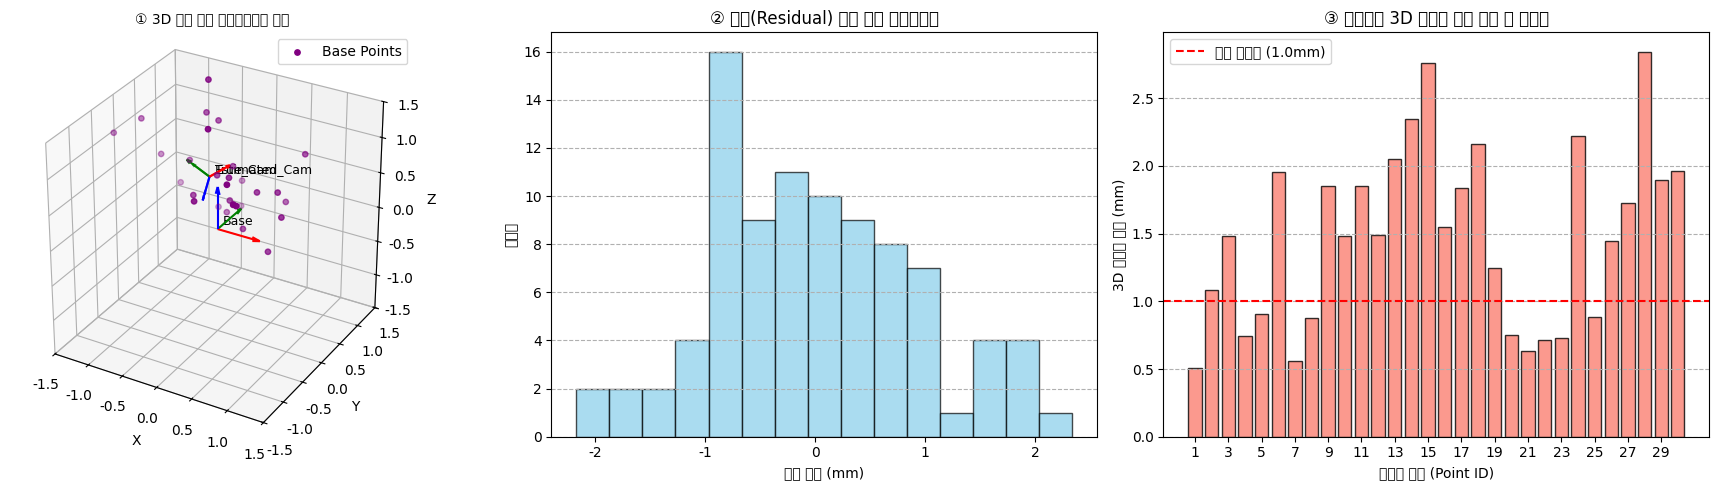

In [237]:
# TODO: 그래프 2개를 그리세요.
#   왼쪽  : 잔차 분포 히스토그램 (단위 mm)
#   오른쪽: 대응점별 재투영 오차 막대그래프 + 주입 노이즈 기준선
fig = plt.figure(figsize=(18, 5))

# [플롯 1] 3D 공간 시각화 (setup_axes와 draw_frame 사용 조건 충족)
ax_3d = fig.add_subplot(1, 3, 1, projection='3d')
setup_axes(ax_3d, "① 3D 공간 상의 캘리브레이션 뼈대", lim=1.5)
draw_frame(ax_3d, np.eye(4), scale=0.6, name="Base")
draw_frame(ax_3d, T_true, scale=0.4, name="True_Cam")

# 복원된 M_hat을 4x4 동차행렬 형태로 임시 확장하여 시각화에 적용
T_hat = np.eye(4)
T_hat[:3, :] = M_hat
draw_frame(ax_3d, T_hat, scale=0.3, alpha=0.7, name="Estimated_Cam")

# 대응점들 3D 공간에 산점도로 뿌리기
ax_3d.scatter(P_base[:, 0], P_base[:, 1], P_base[:, 2], color='purple', s=15, label='Base Points')
ax_3d.legend()

# [플롯 2] 잔차 성분 분포 히스토그램 (mm 단위)
ax_hist = fig.add_subplot(1, 3, 2)
ax_hist.hist(r_vec * 1000, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
ax_hist.set_xlabel('잔차 크기 (mm)')
ax_hist.set_ylabel('빈도수')
ax_hist.set_title('② 잔차(Residual) 오차 성분 히스토그램')
ax_hist.grid(axis='y', ls='--')

# [플롯 3] 대응점별 3D 재투영 오차 계산 및 바 플롯 (mm 단위)
ax_bar = fig.add_subplot(1, 3, 3)
reprojection_errors = [np.linalg.norm(P_base[i] - M_hat @ np.append(P_cam[i], 1.0)) * 1000 for i in range(N_PTS)]

ax_bar.bar(range(1, N_PTS + 1), reprojection_errors, color='salmon', edgecolor='black', alpha=0.8)
ax_bar.axhline(y=NOISE * 1000, color='red', ls='--', lw=1.5, label=f'주입 노이즈 ({NOISE*1000:.1f}mm)')
ax_bar.set_xlabel('대응점 번호 (Point ID)')
ax_bar.set_ylabel('3D 재투영 오차 (mm)')
ax_bar.set_title('③ 대응점별 3D 재투영 오차 분포 및 기준선')
ax_bar.set_xticks(range(1, N_PTS + 1, 2))
ax_bar.legend()
ax_bar.grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

In [238]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 과결정 문제인가 (식 개수 > 미지수 개수)
cond23 = A_ls.shape[0] > A_ls.shape[1]
check("과결정 문제인가 (식 개수 > 미지수 개수)", cond23)
#   - 정규방정식 해가 np.linalg.lstsq 와 일치하는가
cond24 = np.allclose(x_hat, x_lstsq)
check("정규방정식 해가 np.linalg.lstsq 와 일치하는가", cond24)
#   - 잔차가 A 의 열공간에 수직인가 (A^T r = 0)
cond25 = ortho_condition < 1e-10
check("잔차가 A 의 열공간에 수직인가 (A^T r = 0)", cond25)
#   - 추정한 M 이 참값에 충분히 가까운가
cond26 = np.allclose(M_hat,M_true, atol=1e-2)
check("추정한 M 이 참값에 충분히 가까운가", cond26)
#   - 잔차 RMSE 가 주입 노이즈와 같은 자릿수인가
cond27 = np.isclose(res_rmse, NOISE, atol=5e-4)
check("잔차 RMSE 가 주입 노이즈와 같은 자릿수인가", cond27)
#   - (보너스) 해를 살짝 흔들면 잔차가 정말 커지는가 = 최소인가
x_perturbed = x_hat + rng.normal(0.0, 1e-4, 12)
res_rmse_pertubed = rmse(b_ls, A_ls @ x_perturbed)

cond28 = res_rmse_pertubed > res_rmse
check("(보너스) 해를 살짝 흔들면 잔차가 정말 커지는가 = 최소인가", cond28)

[PASS] 과결정 문제인가 (식 개수 > 미지수 개수)
[PASS] 정규방정식 해가 np.linalg.lstsq 와 일치하는가
[PASS] 잔차가 A 의 열공간에 수직인가 (A^T r = 0)
[PASS] 추정한 M 이 참값에 충분히 가까운가
[PASS] 잔차 RMSE 가 주입 노이즈와 같은 자릿수인가
[PASS] (보너스) 해를 살짝 흔들면 잔차가 정말 커지는가 = 최소인가


True

## 답안 템플릿 정리

In [239]:
summary = f"""
1. 역변환 검증: 단위행렬 여부 {np.allclose(T @ Ti, I_4)} / 일반 역행렬과 일치 {cond2}
   - 사용한 공식: T^-1 = [[R^T, -R^T @ t], [0^T, 1]]

2. 점 변환 결과: {p_trans} / 방향 변환 결과: {d_trans}
   - 차이의 이유: w = 0인 방향은 회전성분의 영향없이 회전만 하고(Rx) w = 1인 점은 회전과 이동 둘 다 영향을 줘서(Rx+t)
   - 두 결과의 차이가 무엇과 같은가: 동차변환에서의 t와 동일

3. 합성 순서 비교 그림: 위 3분할 그림 참조
   - T1@T2 병진 {C12[:3, 3]} vs T2@T1 병진 {C21[:3, 3]}
   - 달라지는 이유: 행렬의 곱셈은 교환법칙이 성립하지 않으며 회전 행렬이 후행하는 평행이동 벡터를 축 공간 상에서 함께 회전

4. inv_T 와 일반 역행렬 속도
   - 단건 호출 : {t_single_inv_T * 1e6:.2f} us / {t_single_np_inv * 1e6:.2f} us
   - 배치 {N_BATCH} 개 : {t_batch_inv_T * 1000:.3f} ms / {t_batch_np_inv * 1000:.3f} ms
   - 차이의 이유: 단건은 파이썬 함수 호출 오버헤드가 지배적이라 차이가 가려지나, 배치는 루프 오버헤드가 제거되어 순수 연산량 격차가 그대로 하드웨어 속도로 반영

5. 최소자승 해: {x_hat[:4]}
   - lstsq 와 일치: {cond24}
   - 잔차 RMSE: {res_rmse:.6f} m (= {res_rmse * 1000:.3f} mm), 주입 노이즈 sigma = 1.0 mm
   - 잔차가 열공간에 수직임을 보인 값 |A^T r| = {ortho_condition:.4e}
"""
print(summary)


1. 역변환 검증: 단위행렬 여부 True / 일반 역행렬과 일치 True
   - 사용한 공식: T^-1 = [[R^T, -R^T @ t], [0^T, 1]]

2. 점 변환 결과: [0.912372 0.412372 0.95    ] / 방향 변환 결과: [0.612372 0.612372 0.5     ]
   - 차이의 이유: w = 0인 방향은 회전성분의 영향없이 회전만 하고(Rx) w = 1인 점은 회전과 이동 둘 다 영향을 줘서(Rx+t)
   - 두 결과의 차이가 무엇과 같은가: 동차변환에서의 t와 동일

3. 합성 순서 비교 그림: 위 3분할 그림 참조
   - T1@T2 병진 [0.5 0.3 0.4] vs T2@T1 병진 [0.6 0.  0.6]
   - 달라지는 이유: 행렬의 곱셈은 교환법칙이 성립하지 않으며 회전 행렬이 후행하는 평행이동 벡터를 축 공간 상에서 함께 회전

4. inv_T 와 일반 역행렬 속도
   - 단건 호출 : 3.02 us / 2.94 us
   - 배치 2000 개 : 0.108 ms / 0.433 ms
   - 차이의 이유: 단건은 파이썬 함수 호출 오버헤드가 지배적이라 차이가 가려지나, 배치는 루프 오버헤드가 제거되어 순수 연산량 격차가 그대로 하드웨어 속도로 반영

5. 최소자승 해: [ 0.769606 -0.581077  0.26646  -0.624834]
   - lstsq 와 일치: True
   - 잔차 RMSE: 0.000936 m (= 0.936 mm), 주입 노이즈 sigma = 1.0 mm
   - 잔차가 열공간에 수직임을 보인 값 |A^T r| = 8.2617e-15

